In [ ]:
import pandas as pd

url1= "D:/04_IronHack_DA/IRONHACK_LABS_PROJECTS/IH_Project-3/covid.csv"  # Data from Kaggel (vaccines)
df = pd.read_csv(url1)



url2="D:/04_IronHack_DA/IRONHACK_LABS_PROJECTS/IH_Project-3/df_death_rate.csv" #Data from API (death rate, recovery rate)
df_death_rate = pd.read_csv(url2)


In [ ]:
df_location_vaccine = df[["location", "vaccines"]] # created a new dataframe from the kaggel dataframe with columns location and vaccines

df_location_vaccine["vaccine_count"] = df_location_vaccine["vaccines"].apply(lambda x : len(x.split(","))) # created a new column "vaccine_count" by splitting with commas and counting the number of vaccined for each country


df_location_vaccine.to_csv(r"D:\04_IronHack_DA\IRONHACK_LABS_PROJECTS\IH_Project-3\df_location_vaccine.csv")
df_location_vaccine


In [ ]:
df_merged = pd.merge(df_death_rate, df_location_vaccine, left_on="country", right_on="location", how = "inner") # merged the API data and the kaggel data on country names




df_merged.to_csv(r"D:\04_IronHack_DA\IRONHACK_LABS_PROJECTS\IH_Project-3\df_merged.csv")
df_merged.columns

In [ ]:
#Hypothesis - 1 "Countries with more vaccine types have lower deaths per million"



def bucket(x):   # Function for grouping the countries based on their vaccine counts
    if x<=2:
        return "1-2 vaccines"
    elif x <=5:
        return "3-5 vaccines"
    else:
        return "6+ vaccines"

df_merged["vaccine_group"]=df_merged["vaccine_count"].apply(bucket)
  
result=df_merged.groupby("vaccine_group")["deathsPerOneMillion"].mean()


# group sizes are unequal and results may be influence by factors like healthcare infrastructure and country wealth.

import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))

plt.pie(
    result.values,
    labels=result.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Do more vaccine types mean fewer deaths per million?')
plt.tight_layout()
plt.savefig(r'D:\04_IronHack_DA\IRONHACK_LABS_PROJECTS\IH_Project-3\hypothesis1.png', dpi=150)
plt.show()


In [ ]:
#Hypothesis - 2 "Countries using eastern vaccines Vs Western vaccines to different death rates"


import matplotlib.pyplot as plt

#Classify each country as Western / Eastern / Mixed
western = ['Pfizer/BioNTech', 'Moderna']
eastern = ['Sinopharm/Beijing', 'Sinovac', 'Sputnik V', 'Sputnik Light', 
           'Sinopharm/Wuhan', 'CanSino']

def classify(vaccine_str):
    has_western = any(w in vaccine_str for w in western)
    has_eastern = any(e in vaccine_str for e in eastern)
    
    if has_western and not has_eastern:
        return 'Western Only'
    elif has_eastern and not has_western:
        return 'Eastern Only'
    elif has_western and has_eastern:
        return 'Mixed'
    else:
        return 'Other'

df_location_vaccine['vaccine_type'] = df_location_vaccine['vaccines'].apply(classify)

# See how many countries are in each group

#print(df_location_vaccine['vaccine_type'].value_counts())


#Calculate death rate from API
df_death_rate['death_rate'] = (df_death_rate['deaths'] / df_death_rate['cases'] * 100).round(2)



#Merge both sources
df_merged_h2 = pd.merge(df_death_rate, df_location_vaccine[['location', 'vaccine_type']],
                         left_on='country', right_on='location', how='inner')

df_merged_h2.to_csv(r"D:\04_IronHack_DA\IRONHACK_LABS_PROJECTS\IH_Project-3\df_merged_h2.csv")
#df_merged_h2.columns

# Keep the order you want on x-axis
group_order = ['Western Only', 'Eastern Only', 'Mixed', 'Other']

# Average death rate per group
result_h2 = df_merged_h2.groupby('vaccine_type')['death_rate'].mean().reindex(group_order)

# Number of countries per group
counts_h2 = df_merged_h2.groupby('vaccine_type')['country'].count().reindex(group_order)





# Bar plot 

label_map = {
    'Western Only': 'Western',
    'Eastern Only': 'Eastern',
    'Mixed': 'Mixed',
    'Other': 'Other'
}

x_labels = [label_map[g] for g in result_h2.index]

# Plot

colors = ['green', 'orange', 'red', 'gold']
bars = ax.bar(x_labels, result_h2.values, color=colors)

fig, ax = plt.subplots(figsize=(9, 6))

colors = ['green', 'orange', 'red', 'gold']
bars = ax.bar(x_labels, result_h2.values, color=colors)

for bar, val in zip(bars, result_h2.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')

for bar, count in zip(bars, counts_h2.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            f'Countries={count}', ha='center', va='center',
            fontsize=11, color='white', fontweight='bold')

ax.set_title('Western vs Eastern Vaccine Groups and Average Death Rate', fontsize=13)
ax.set_xlabel('Vaccine Group')
ax.set_ylabel('Average Death Rate (%)')
ax.set_ylim(0, result_h2.max() + 0.3)
plt.tight_layout()
plt.savefig(r'D:\04_IronHack_DA\IRONHACK_LABS_PROJECTS\IH_Project-3\hypothesis2.png', dpi=150)
plt.show()



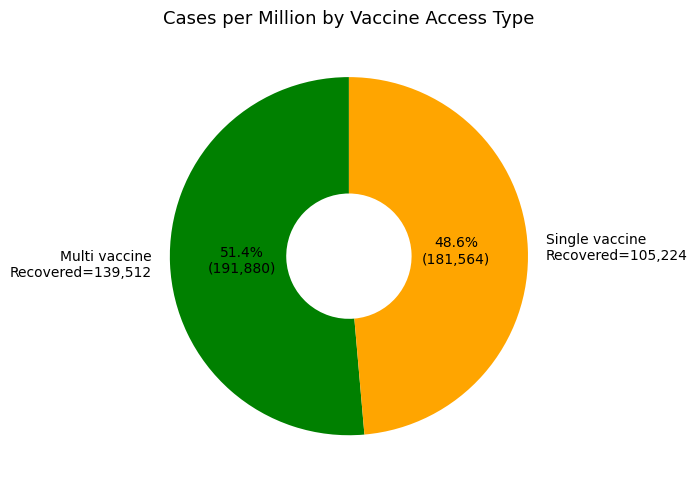

vaccine_access_type
Multi vaccine     168
Single vaccine     26
Name: country, dtype: int64

In [84]:
# Hypothesis 3 - "Countries with access to multiple vaccines demonstrated higher recoveries per one million case."

def vaccine_access(v):

    if v == 1:
        return "Single vaccine"
    else:
        return "Multi vaccine"

df_location_vaccine["vaccine_access_type"]=df_location_vaccine["vaccine_count"].apply(vaccine_access)


df_merged_h3 = pd.merge(df_death_rate, df_location_vaccine[['location','vaccine_access_type']],
                         left_on='country', right_on='location', how='inner')

df_merged_h3.head()
df_merged_h3.to_csv(r'D:\04_IronHack_DA\IRONHACK_LABS_PROJECTS\IH_Project-3\df_merged_h3.csv')

# grouping by no. of vaccines each couuntry had 1 or multi
result_h3 = df_merged_h3.groupby('vaccine_access_type')['casesPerOneMillion'].mean()

# Number of countries per group
counts_h3 = df_merged_h3.groupby('vaccine_access_type')['country'].count()

recovered_h3 = df_merged_h3.groupby('vaccine_access_type')['recoveredPerOneMillion'].mean()


# Plot
x_labels = ["Multi vaccine", "Single vaccine"]
colors = ['green', 'orange']

labels = [
    f"{group}\nRecovered={recovered:,.0f}"
    for group, recovered in zip(x_labels, recovered_h3.values)
]

def autopct_with_values(values):
    def inner(pct):
        total = sum(values)
        val = pct * total / 100
        return f"{pct:.1f}%\n({val:,.0f})"
    return inner

fig, ax = plt.subplots(figsize=(7, 5))

wedges, texts, autotexts = ax.pie(
    result_h3.values,
    labels=labels,
    colors=colors,
    autopct=autopct_with_values(result_h3.values),
    startangle=90,
    wedgeprops=dict(width=0.65)
)

ax.set_title('Cases per Million by Vaccine Access Type', fontsize=13)

plt.tight_layout()
plt.savefig(r'D:\04_IronHack_DA\IRONHACK_LABS_PROJECTS\IH_Project-3\hypothesis3.png', dpi=150)
plt.show()

counts_h3
  

In [ ]:
# Hypothesis 4: Countries with only Oxord/Astrazeneca as a vaccine varaint had fewer deaths per million than countries using 
# Pfizer/Moderna or other vaccines.


def astra_classify(vaccine_variant):
    has_astra = "Oxford/AstraZeneca" in vaccine_variant 
    has_pfizer = any(p in vaccine_variant for p in ["Pfizer/BioNTech","Moderna"]) 
    
    if has_astra and not has_pfizer:
        return 'Oxford/AstraZeneca'
    elif has_pfizer and not has_astra:
        return "Pfizer/Moderna"
    else:
        return 'Other'


df_location_vaccine["vaccine_variant"] = df_location_vaccine["vaccines"].apply(astra_classify)

df_merged_h4 = pd.merge(df_death_rate, df_location_vaccine[['location','vaccine_variant']],left_on='country', right_on='location', how='inner')

order = ["Oxford/AstraZeneca", "Pfizer/Moderna",  "Other"]

# grouping by vaccine_variant each couuntry had
result_h4 = df_merged_h4.groupby('vaccine_variant')['deathsPerOneMillion'].mean().reindex(order)

# Number of countries per group
counts_h4 = df_merged_h4.groupby('vaccine_variant')['country'].count().reindex(order)


# Plot

colors = ['green', 'orange', 'grey']

labels = [
    f"{variant}\nCountries={count:,.0f}"
    for variant, count in zip(order, counts_h4.values)
]

def autopct_with_values(values):
    def inner(pct):
        total = sum(values)
        val = pct * total / 100
        return f"{pct:.1f}%\n({val:,.0f})"
    return inner

fig, ax = plt.subplots(figsize=(7, 5))

ax.pie(
    result_h4.values,
    labels=labels,
    colors=colors,
    autopct=autopct_with_values(result_h4.values),
    startangle=90,
    wedgeprops=dict(width=0.65)
)

ax.set_title('Average deaths per Million by Vaccine Variant', fontsize=13)

plt.tight_layout()
plt.savefig(r'D:\04_IronHack_DA\IRONHACK_LABS_PROJECTS\IH_Project-3\hypothesis4.png', dpi=150)
plt.show()

In [ ]:
# list of countries in descending order according to the deaths Per One Million

astra=df_merged_h4[df_merged_h4["vaccine_variant"] == "Oxford/AstraZeneca"] [["country", 
            "deathsPerOneMillion"]].sort_values("deathsPerOneMillion",ascending = False)

moderna=df_merged_h4[df_merged_h4["vaccine_variant"] == "Pfizer/Moderna"] [["country", 
            "deathsPerOneMillion"]].sort_values("deathsPerOneMillion",ascending = False)

other=df_merged_h4[df_merged_h4["vaccine_variant"] == "Other"] [["country", 
            "deathsPerOneMillion"]].sort_values("deathsPerOneMillion",ascending = False)



# Data from kaggel with list of countreis and their populations
url3="D:/04_IronHack_DA/IRONHACK_LABS_PROJECTS/IH_Project-3/country_population.csv"
country_population=pd.read_csv(url3)

country_population_2020=country_population[["Country (or dependency)","Population (2020)" ]]  # new data frame with just country and population
country_population_2020=country_population_2020.rename(columns={"Country (or dependency)": "country"}) #Column "Country (or dependency)" changed to "country" 
country_population_2020=country_population_2020.rename(columns={"Population (2020)": "population (2020)"}) # Column "Population (2020)" changed to "population"

#country_population_2020.to_csv(r"D:\04_IronHack_DA\IRONHACK_LABS_PROJECTS\IH_Project-3\country_population_2020.csv")


# new dataframe: Population + astra / moderna /other
df_population_astra = pd.merge(country_population_2020, astra,left_on='country', right_on='country', how='inner')
df_population_moderna = pd.merge(country_population_2020, moderna,left_on='country', right_on='country', how='inner') 
df_population_other = pd.merge(country_population_2020, other,left_on='country', right_on='country', how='inner') 


# Added a new column "stats" to the data frames. Calculation: stats = (deathsPerOneMillion/population (2020))*100
df_population_astra["stats"]= ((df_population_astra["deathsPerOneMillion"] / df_population_astra["population (2020)"])*100).round(3)
df_population_moderna["stats"]= ((df_population_moderna["deathsPerOneMillion"] / df_population_moderna["population (2020)"])*100).round(3)
df_population_other["stats"]= ((df_population_other["deathsPerOneMillion"] / df_population_other["population (2020)"])*100).round(3)


df_population_other.to_csv(r"D:\04_IronHack_DA\IRONHACK_LABS_PROJECTS\IH_Project-3\df_population_other.csv")
